    # 2. The pass that looks clean

    **Week 1, Friday. The lab debrief, chapter 2 of 3: the rows reconcile, so is the pass finished?**

    Anand Iyer's analyst audits every note that reaches Meera. Their first question is never "how many
    rows did you drop"; it is "show me the rupees". A pass that reports zero rejects on a file everyone
    knows is dirty is the one they open first.

    **The metric at stake.** Q1 booked revenue, the base every Q1 to Q2 rate is measured from.
    **Who asks.** Anand's analyst, auditing the note, and Meera, who reads the size of the fall as the
    size of the problem. **What a wrong number costs.** A base that is short by one large order halves
    the fall the note reports, so Monday's review sizes the problem at half its real size and the fix
    gets half the attention; when Finance finds the missing order, every other number in the note is
    doubted with it.

    **Who else faces this.** JPMorgan Chase's own task force, reviewing the 2012 "London Whale" losses, found
    that a risk model run through spreadsheets "divided by their sum instead of their average", which
    "likely had the effect of muting volatility by a factor of two and of lowering the VaR" (the task
    force report of January 2013, as quoted by The Baseline Scenario, 9 February 2013). The trading
    losses came to $6.2 billion (FCA, 19 September 2013). Nothing crashed: the sheet produced a
    plausible number every day.

    **Where this starts.** Chapter 1 left one run at -14.6 percent: the order counts landed and the
    rupees did not. This chapter finds out why, sizes the four ways to handle a value that will not
    convert, and then meets the same shape one step later, where a segment filter drops a row without a
    word. Chapter 3 takes the repaired numbers into the tree.

**Before you read on.** This notebook runs on this morning's lab export and shows the morning's
numbers. It opens after the lab clock stops, and it is the debrief's text for self-study too.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import random
import statistics
import time

rows = kit.load_csv("C2_W01_D05_lab_orders_STUDENT.csv")
control = {c["quarter"]: c for c in kit.load_csv("C2_W01_D05_lab_control_STUDENT.csv")}
QUARTERS = ("Q1", "Q2")


def change(a, b):
    """Percentage change from a to b."""
    return 100 * (b / a - 1)


def ctl(q):
    return int(control[q]["amount_rs"]), int(control[q]["orders"])


print(f"{len(rows)} rows read from the lab export; Finance's control totals for {', '.join(sorted(control))}")


def first_of_each(src):
    kept = {}
    for r in src:
        kept.setdefault(r["order_id"], r)
    return list(kept.values())


once = first_of_each(rows)
print(f"{len(once)} orders after the identity rule from chapter 1")

207 rows read from the lab export; Finance's control totals for Q1, Q2
197 orders after the identity rule from chapter 1


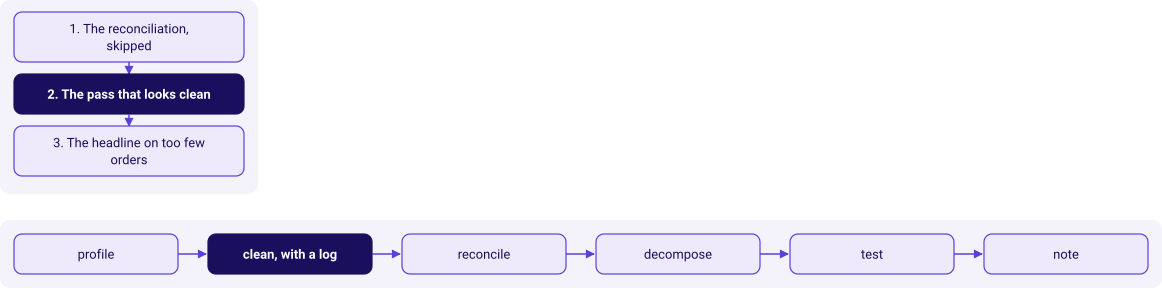

In [2]:
kit.side_by_side(
    kit.ladder(["The reconciliation, skipped", "The pass that looks clean", "The headline on too few orders"],
               lit=1, show=False),
    kit.flow(["profile", "clean, with a log", "reconcile", "decompose", "test", "note"], lit=1, show=False),
)

## 1. Zero rejects, and the counts reconcile

The most natural line of Python in the week wraps the conversion in a `try` and sets a failure to
zero. It never stops, it reports nothing, and every row survives.

**Predict before you run.** The pass keeps one row per order and sets any value that will not
convert to zero. How many orders does Q1 report against Finance's 98, and how many rejects?

- a) 97 orders and 1 reject.
- b) 98 orders and 0 rejects.
- c) 98 orders and 1 reject.
- d) 108 orders and 0 rejects.

In [3]:
def to_int_or_zero(v):
    try:
        return int(v)
    except ValueError:
        return 0          # the file now "converts" cleanly


zeroed = {q: [to_int_or_zero(r["amount"]) for r in once if r["quarter"] == q] for q in QUARTERS}
kit.stats([(len(zeroed["Q1"]), "Q1 orders", f"Finance: {ctl('Q1')[1]}"),
           (0, "rejects reported", "the try swallowed every failure"),
           (kit.rupees(sum(zeroed["Q1"])), "Q1 as summed", "the base of every rate")])
kit.check("the zeroing pass lands on Finance's order counts", all(len(zeroed[q]) == ctl(q)[1] for q in QUARTERS))

**What happened.** The answer is b. Every order count lands and nothing is rejected, which is exactly
what a finished pass looks like.

## 2. The trap: the rupees do not

**The plausible wrong answer.** "Q1 Rs 50,63,000 on 98 orders, zero rejects, counts reconciled; Q2
fell 14.6 percent." Every word of it can be defended except the first number.

**Predict before you run.** Q1 against Finance's control total: by how much, and which way?

- a) It lands to the rupee.
- b) Over by about Rs 10 lakh.
- c) Short by about Rs 10 lakh.
- d) Short by a few thousand rupees of rounding.

quarter,orders,Finance's orders,summed,Finance's rupees,gap
Q1,98,98,"Rs 50,63,000","Rs 60,48,000","Rs 9,85,000"
Q2,99,99,"Rs 43,25,480","Rs 43,25,480",Rs 0


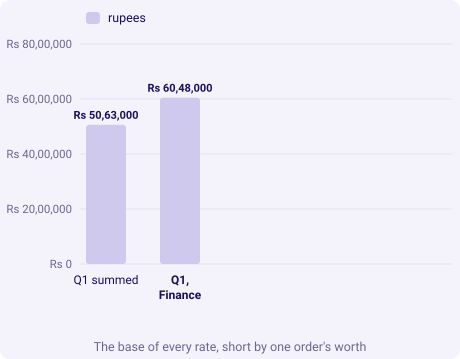

In [4]:
gap = {q: ctl(q)[0] - sum(zeroed[q]) for q in QUARTERS}
kit.table(["quarter", "orders", "Finance's orders", "summed", "Finance's rupees", "gap"],
          [(q, len(zeroed[q]), ctl(q)[1], kit.rupees(sum(zeroed[q])), kit.rupees(ctl(q)[0]), kit.rupees(gap[q]))
           for q in QUARTERS], caption="Counts land; rupees do not")
kit.columns(["Q1 summed", "Q1, Finance"], [("rupees", [sum(zeroed["Q1"]), ctl("Q1")[0]])], width=460,
            fmt=lambda v: kit.rupees(v), lit=(1,), title="The base of every rate, short by one order's worth")
kit.check("Q1 is short of the control total while Q2 lands", gap["Q1"] > 0 and gap["Q2"] == 0,
          kit.rupees(gap["Q1"]) + " short in Q1")

**What happened.** The answer is c. The counts reconcile and Q1 is short by Rs 9,85,000, which is 16.3
percent of the quarter.

**Why it is wrong.** The `try` turned "I could not read this value" into "this order was worth
nothing", and zero is a number, so no later step can tell the difference. A count check cannot see
it, because the row is still there. The note reports a fall of 14.6 percent where the books show
28.5: the direction is right, so nobody argues, and the size is half, so nobody acts at the right
scale. The check that catches it is the one chapter 1 made standard, the rupees against the control
total.

## The options

One value in 207 will not convert. What a team does with it is a decision, and it goes in the log
either way. The cell below sizes the four answers on this file: the rows touched, what the log and
the reconciliation then show, and the headline each one sends. The minutes are this programme's
estimate, and D's is a wait on another team.

| Option | What it does |
|---|---|
| A. Zero in a try | Sets the value to 0 and says nothing |
| B. Drop with a reason | Rejects the row and logs why |
| C. Read it, convert, keep and flag | Reads the value without guessing, logs the text and the number |
| D. Hold and ask the owner | Leaves the row out of today's totals until the order's owner confirms the amount |

option,analyst minutes,rows touched,log lines,count check,rupee check,headline sent
A,1,1,0,passes,fails,-14.6%
B,2,1,1,fails,fails,-14.6%
C,3,1,1,passes,passes,-28.5%
D,240,1,1,fails,fails,-14.6%


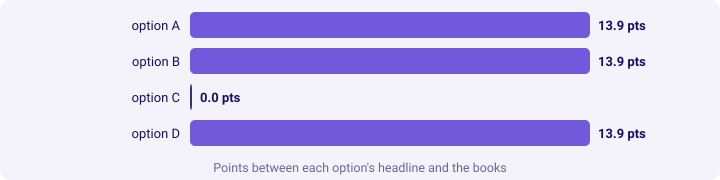

In [5]:
def read_amount(v):
    """Digits only, when every character is a digit or a grouping comma; otherwise None."""
    text = v.strip()
    if text and all(ch.isdigit() or ch == "," for ch in text) and text[0].isdigit():
        return int(text.replace(",", ""))
    return None


def run_option(option):
    kept, log = {q: 0 for q in QUARTERS}, []
    counts = {q: 0 for q in QUARTERS}
    for r in once:
        v = r["amount"]
        if v.isdigit():
            kept[r["quarter"]] += int(v)
            counts[r["quarter"]] += 1
            continue
        if option == "A":
            counts[r["quarter"]] += 1
        elif option == "B":
            log.append("drop: value will not convert")
        elif option == "C":
            kept[r["quarter"]] += read_amount(v)
            counts[r["quarter"]] += 1
            log.append("convert and flag: grouping commas removed")
        else:
            log.append("held: asked the order's owner")
    return kept, counts, log


truth = change(ctl("Q1")[0], ctl("Q2")[0])
opt_rows, pts = [], []
for option, minutes in [("A", 1), ("B", 2), ("C", 3), ("D", 240)]:
    kept, counts, log = run_option(option)
    reported = change(kept["Q1"], kept["Q2"])
    count_ok = all(counts[q] == ctl(q)[1] for q in QUARTERS)
    rupee_ok = all(kept[q] == ctl(q)[0] for q in QUARTERS)
    opt_rows.append((option, minutes, 1, len(log), "passes" if count_ok else "fails",
                     "passes" if rupee_ok else "fails", f"{reported:+.1f}%"))
    pts.append((option, abs(reported - truth)))
kit.table(["option", "analyst minutes", "rows touched", "log lines", "count check", "rupee check", "headline sent"],
          opt_rows, caption="Four answers to one value that will not convert, sized on the lab export")
kit.bars([(f"option {o}", round(p, 1)) for o, p in pts], lit=(2,), fmt=lambda v: f"{v:.1f} pts",
         title="Points between each option's headline and the books")

In [6]:
kit.check("only A leaves no trace in the log", [r[3] for r in opt_rows] == [0, 1, 1, 1])
kit.check("B fails the count check, so its gap is visible", opt_rows[1][4] == "fails")
kit.check("C passes both checks", opt_rows[2][4] == opt_rows[2][5] == "passes")

**The best-fit call.** C. The value can be read without guessing, since it is digits with the
grouping commas an Indian ledger prints, so converting it costs a minute and one log line and lands
both quarters on the books. A is the only option that is never right: it produces the same wrong
headline as B and hides it. B is honest and still wrong by 14 points; its virtue is that the count
check now fails, so the gap is visible. D is right on the day the text could be read two ways.

**What would change the call.** Text that cannot be read without a guess moves the call to D: a
value written as a word, a decimal whose unit is unclear (lakh or crore), a currency that is not the
file's. A row that is not an order at all, a test transaction, moves it to B. In every case the log
line and the reconciliation carry the decision, and zero never does.

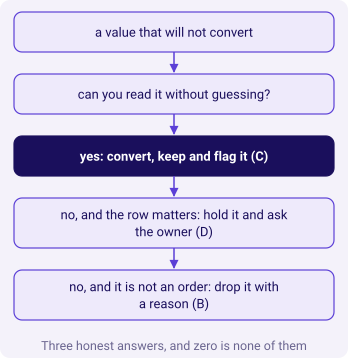

In [7]:
kit.vflow(["a value that will not convert",
           "can you read it without guessing?",
           "yes: convert, keep and flag it (C)",
           "no, and the row matters: hold it and ask the owner (D)",
           "no, and it is not an order: drop it with a reason (B)"], lit=2,
          title="Three honest answers, and zero is none of them")

**Your turn.** Find the row the bridge points at and read its value yourself. Type these lines into
the empty cell below and run it:

```python
for r in once:
    if not r["amount"].isdigit():
        print(r)
```

Then write the decisions-log line you would hand Anand's analyst: the order id, the decision and the
reason, in one row.

## 3. The fix, and what it changes

**Predict before you run.** With option C, what does the note's first line become?

- a) Q2 down 14.6 percent, unchanged.
- b) Q2 down 28.5 percent.
- c) Q2 up 11.8 percent.
- d) Q2 down 16.3 percent.

In [8]:
fixed, fixed_counts, fixed_log = run_option("C")
kit.table(["", "Q1", "Q2", "Q1 to Q2"],
          [("zero in a try", kit.rupees(sum(zeroed["Q1"])), kit.rupees(sum(zeroed["Q2"])),
            f"{change(sum(zeroed['Q1']), sum(zeroed['Q2'])):+.1f}%"),
           ("read, convert, flag", kit.rupees(fixed["Q1"]), kit.rupees(fixed["Q2"]),
            f"{change(fixed['Q1'], fixed['Q2']):+.1f}%")], caption="The same rows, two decisions about one value")
kit.check("the fixed pass lands on both control totals", all(fixed[q] == ctl(q)[0] for q in QUARTERS))

,Q1,Q2,Q1 to Q2
zero in a try,"Rs 50,63,000","Rs 43,25,480",-14.6%
"read, convert, flag","Rs 60,48,000","Rs 43,25,480",-28.5%


**What happened.** The answer is b. One log line moves the reported fall from 14.6 to 28.5 percent,
which is Rs 17,22,520 of fall where the zeroing pass reported Rs 7,37,520. In the review, that is the
difference between "a soft quarter" and "a quarter to explain".

## 4. The same shape one step later: a segment that quietly loses a row

A pass looks clean whenever a step can lose something without saying so. The next place it happens
is the tree: a filter on the segment name never sees a row whose segment is empty.

**Predict before you run.** The four named segments are summed per quarter. Do they add back to the
quarter's total?

- a) Yes, in orders and in rupees.
- b) In orders, but not in rupees.
- c) No, one quarter is short by one order and its value.
- d) No, both quarters are short by several orders.

In [9]:
SEGS = ("Retail-Core", "Retail-Plus", "Student", "Business")
amt = lambda r: int(r["amount"].replace(",", ""))
seg_sum = {q: sum(amt(r) for r in once if r["quarter"] == q and r["segment"] in SEGS) for q in QUARTERS}
seg_n = {q: sum(1 for r in once if r["quarter"] == q and r["segment"] in SEGS) for q in QUARTERS}
kit.table(["quarter", "named segments, orders", "Finance's orders", "named segments, rupees", "Finance's rupees"],
          [(q, seg_n[q], ctl(q)[1], kit.rupees(seg_sum[q]), kit.rupees(ctl(q)[0])) for q in QUARTERS],
          caption="Segments summed against the quarter")
kit.check("Q2's named segments fall one order short of the quarter",
          ctl("Q2")[1] - seg_n["Q2"] == 1 and seg_n["Q1"] == ctl("Q1")[1])

quarter,"named segments, orders",Finance's orders,"named segments, rupees",Finance's rupees
Q1,98,98,"Rs 60,48,000","Rs 60,48,000"
Q2,98,99,"Rs 43,22,550","Rs 43,25,480"


**What happened.** The answer is c. Q2's named segments hold one order fewer than the quarter.

**The plausible wrong answer.** Read one tier on the named rows only, and a tier that grew shows as a
second falling segment. The cell below computes Retail-Plus both ways: on the named rows, and with
the unnamed order restored to the only segment its customer's other orders carry.

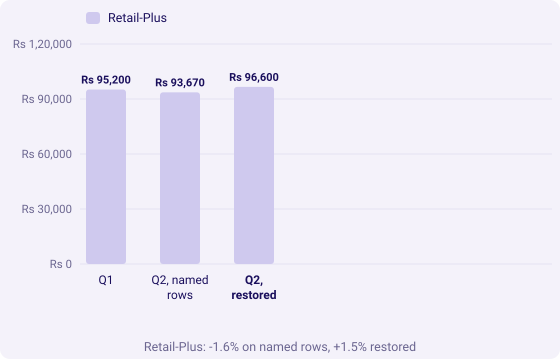

In [10]:
def plus(q, restore):
    rs = [r for r in once if r["quarter"] == q and r["segment"] == "Retail-Plus"]
    if restore:
        seg_of = {}
        for r in once:
            if r["segment"]:
                seg_of.setdefault(r["customer_id"], set()).add(r["segment"])
        rs += [r for r in once if r["quarter"] == q and not r["segment"]
               and seg_of.get(r["customer_id"]) == {"Retail-Plus"}]
    return len(rs), sum(amt(r) for r in rs)


p1, p2n, p2r = plus("Q1", False), plus("Q2", False), plus("Q2", True)
kit.columns(["Q1", "Q2, named rows", "Q2, restored"], [("Retail-Plus", [p1[1], p2n[1], p2r[1]])],
            fmt=lambda v: kit.rupees(v), lit=(2,), width=560,
            title=f"Retail-Plus: {change(p1[1], p2n[1]):+.1f}% on named rows, {change(p1[1], p2r[1]):+.1f}% restored")
kit.check("the empty cell flips Retail-Plus from a fall to a rise",
          change(p1[1], p2n[1]) < 0 < change(p1[1], p2r[1]))

**Why it is wrong, and the fix.** Nobody decided to drop the order; the filter did. The check is one
line, that the segments add back to the quarter in orders and in rupees, and it fails by exactly one
order. The fix is a logged decision: restore the segment from the customer's other orders when all of
them carry one segment, flag it, and name it in the caveat; keep it as "segment unknown" when they do
not.

## A second route: account for every value, not every row

The rupee check found the gap from the outside. The second route finds it from the inside, and it
should land on the same number: every value present in the file is either summed as it came, or
appears in the log with the number it was read as. Present equals convertible plus logged, and the
logged values add up to the gap.

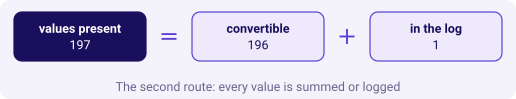

In [11]:
present = sum(1 for r in once if r["amount"] != "")
convertible = sum(1 for r in once if r["amount"].isdigit())
logged = [read_amount(r["amount"]) for r in once if not r["amount"].isdigit()]
kit.equation([f"values present\n{present}", "=", f"convertible\n{convertible}", "+", f"in the log\n{len(logged)}"],
              title="The second route: every value is summed or logged")
kit.check("present equals convertible plus logged", present == convertible + len(logged))
kit.check("the logged values add up to the gap the rupee check found", sum(logged) == gap["Q1"],
          kit.rupees(sum(logged)))

**When to switch routes.** The rupee check needs a control total and tells you how much is missing;
the value accounting needs nothing outside the file and tells you where. On a file with no control
total, the value accounting is the check you still have.

> **Kavya's review.** A count check proves the rows are there. Only a rupee check proves the values
> survived. Zero is a claim that the order was worth nothing, so never let a `try` make it for you.

### In the interview

**[S] Your cleaning pass reports zero rejects. What do you check?** "I distrust the zero before I
trust it. First, rows against distinct ids, because a repeated batch is the commonest reason a total
runs high. Second, how my code handled a value that would not convert: if a `try` set it to zero,
the rejects count is hiding it. Third, the rupees per period against a control total, with a bridge
from my number to theirs. On a lab export a zeroing pass reconciled every count and still left the
base quarter Rs 9,85,000 short, which halved the fall the note reported."

**[F] How do you handle a value that will not convert?** "Three honest answers: read it and convert
it when it can be read without guessing, hold it and ask the owner when it cannot, drop it with a
reason when the row is not an order. Every one gets a log line and shows in the reconciliation.
Setting it to zero is the one answer I never give, because zero is a number and nothing later can
tell it from a real one."

**The design question: when would you drop the row rather than read it?** "When the row is not the
thing being counted, a test order or a cancelled draft, and the log says so. When the value matters
and I cannot read it without guessing, I hold it and ask, and the note says the quarter is
provisional by that amount."

### Depth: where else a pass looks clean

Any step that can lose something silently: a join that drops rows without a match, a date parse
that sends a bad date to a default, a `groupby` that leaves out a missing key (Week 2 meets that
one in pandas), a filter on a name that is sometimes blank. The pattern is always the same check:
what went in equals what came out plus what was set aside, in rows and in value.

In [12]:
kit.check_summary()